<a href="https://colab.research.google.com/github/arya-arun-123/Blood_Cell_Classification_Model/blob/main/PCB.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#LIBRARIES

In [1]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image


import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.metrics import  classification_report,confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense, Dropout, Lambda
from tensorflow.keras.optimizers import Adam

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# READ DATASET

In [3]:
# dataset
filepath= "/content/drive/MyDrive/AI  and ML/DataSets/PBC_dataset_normal_DIB"

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42


### inspect classes

In [4]:
classes = sorted(
    d for d in os.listdir(filepath)
    if os.path.isdir(os.path.join(filepath, d))
)
NUM_CLASSES = len(classes)

print("Classes Found:\n")
class_counts = {}
for cls in classes:
    class_path = os.path.join(filepath, cls)
    images = [
        img for img in os.listdir(class_path)
        if img.lower().endswith((".jpg", ".jpeg", ".png"))
    ]
    class_counts[cls] = len(images)
    print(f"{cls:<15} : {len(images)} images")

print(f"\nTotal classes: {NUM_CLASSES}")

Classes Found:

basophil        : 1218 images
eosinophil      : 3117 images
erythroblast    : 1551 images
ig              : 2895 images
lymphocyte      : 1214 images
monocyte        : 1420 images
neutrophil      : 3329 images
platelet        : 2348 images

Total classes: 8


# CREATING TRAINING AND TESTING DATASET

In [5]:
# TRAINING DATASET
# 70 % used for training

train_ds = tf.keras.utils.image_dataset_from_directory(
    filepath,
    validation_split=0.30,
    subset="training",
    seed=SEED,
    image_size = IMG_SIZE,
    batch_size = BATCH_SIZE,
    shuffle=True
)

Found 17092 files belonging to 8 classes.
Using 11965 files for training.


In [6]:
temp_ds = tf.keras.utils.image_dataset_from_directory(
    filepath,
    validation_split=0.30,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True
)


Found 17092 files belonging to 8 classes.
Using 5127 files for validation.


In [7]:
class_names = train_ds.class_names
assert class_names == classes, "Class order mismatch between directory scan and dataset!"
assert len(class_names) == NUM_CLASSES

In [8]:
# VALIDATION AND TEST DATASET
# 15 % - validation datset
# 15 % - testing dataset
temp_batches = tf.data.experimental.cardinality(temp_ds)

val_ds = temp_ds.take(temp_batches // 2)
test_ds = temp_ds.skip(temp_batches // 2)

print("Class order:", class_names)

Class order: ['basophil', 'eosinophil', 'erythroblast', 'ig', 'lymphocyte', 'monocyte', 'neutrophil', 'platelet']


# AUTO TUNING

In [9]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(buffer_size = AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size = AUTOTUNE)
test_ds = test_ds.prefetch(buffer_size = AUTOTUNE)

# This allows to load next batch while training current batch

### CLASS WEIGHTS

In [10]:
labels = list(class_counts.keys())
counts = np.array(list(class_counts.values()))
y_all = np.repeat(np.arange(NUM_CLASSES), counts)

class_weights_arr = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(NUM_CLASSES),
    y=y_all
)
class_weight = {i: w for i, w in enumerate(class_weights_arr)}
print("Class weights:", class_weight)

Class weights: {0: np.float64(1.7541050903119868), 1: np.float64(0.6854347128649342), 2: np.float64(1.377498388136686), 3: np.float64(0.7379965457685665), 4: np.float64(1.7598846787479407), 5: np.float64(1.5045774647887324), 6: np.float64(0.6417843196155002), 7: np.float64(0.909923339011925)}


# AUGMENTATION

In [11]:
# Makes changes in training data to prevent overfitting and improve generalization
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.10)
])

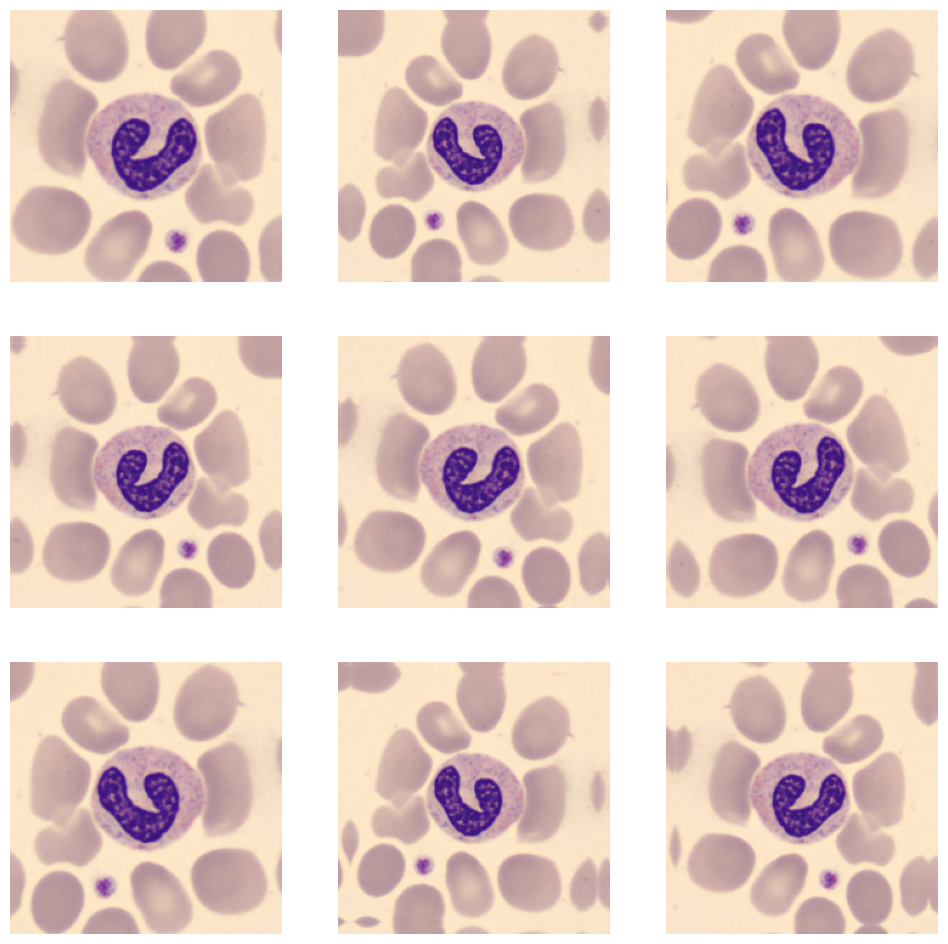

In [12]:
for images, labels in train_ds.take(1):

    plt.figure(figsize = (12, 12))
    first_image = images[0]

    for i in range(9):

        ax = plt.subplot(3, 3, i + 1)
        augmented_image = data_augmentation(tf.expand_dims(first_image, 0))
        plt.imshow(augmented_image[0].numpy().astype("uint8"))
        plt.axis("off")

plt.show()

# NORMALIZATION

In [13]:
normalization_layer = layers.Rescaling(1./255)

# MODEL BUILDING

### MODEL 1 : CUSTOM CNN

In [14]:
cnn_model = tf.keras.Sequential([
    tf.keras.Input(shape = (IMG_SIZE[0],IMG_SIZE[1], 3)),
    data_augmentation,
    normalization_layer,
    # LAYER 1
    layers.Conv2D(
        filters = 32,
        kernel_size = (3,3),
        activation ='relu',
        padding ='same'
    ),

    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size = (2,2)),
    layers.Dropout(0.25),



    # LAYER 2
    layers.Conv2D(
        filters = 64,
        kernel_size = (3,3),
        activation ='relu',
        padding ='same'
    ),

    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size = (2,2)),
    layers.Dropout(0.25),



    # LAYER 3
    layers.Conv2D(
        filters = 128,
        kernel_size=(3,3),
        activation='relu',
        padding='same'
    ),

    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size = (2,2)),
    layers.Dropout(0.30),



    # OUTPUT LAYER
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.50),
    layers.Dense(NUM_CLASSES, activation='softmax')

], name = "custom_cnn")

# COMPILING THE MODEL

In [15]:
cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# CALLBACKS

In [16]:
# Early Stopping
cnn_early_stop = tf.keras.callbacks.EarlyStopping(
    monitor = 'val_loss',
    patience = 5,
    restore_best_weights = True
)

In [17]:
# Checkpointing
cnn_checkpoint = tf.keras.callbacks.ModelCheckpoint(
    "best_cnn_model.keras",
    monitor='val_accuracy',
    save_best_only=True
)

In [18]:
print("TensorFlow Version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))

TensorFlow Version: 2.20.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


# MODEL TRAINING

In [19]:
cnn_history = cnn_model.fit(
    train_ds,
    validation_data = val_ds,
    epochs = 5,
    callbacks=[cnn_early_stop, cnn_checkpoint],
    class_weight = class_weight
)

Epoch 1/5
374/374 ━━━━━━━━━━━━━━━━━━━━ 622s 2s/step - accuracy: 0.2752 - loss: 3.4190 - val_accuracy: 0.0734 - val_loss: 151.0144
Epoch 2/5
374/374 ━━━━━━━━━━━━━━━━━━━━ 105s 280ms/step - accuracy: 0.3352 - loss: 1.9924 - val_accuracy: 0.3684 - val_loss: 2.0211
Epoch 3/5
374/374 ━━━━━━━━━━━━━━━━━━━━ 84s 225ms/step - accuracy: 0.3429 - loss: 1.7994 - val_accuracy: 0.3348 - val_loss: 2.2544
Epoch 4/5
374/374 ━━━━━━━━━━━━━━━━━━━━ 74s 198ms/step - accuracy: 0.3511 - loss: 1.7315 - val_accuracy: 0.3094 - val_loss: 2.1886
Epoch 5/5
374/374 ━━━━━━━━━━━━━━━━━━━━ 70s 187ms/step - accuracy: 0.3455 - loss: 1.7059 - val_accuracy: 0.3656 - val_loss: 1.9605


# MODEL 2 VGG Transfer Learning


## Load the Pre-trained VGG16 Model

In [20]:
base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3)
)
base_model.trainable = False   # freeze pretrained backbone

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


## Building new model

In [21]:
vgg_model = Sequential([
    tf.keras.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3)),
    data_augmentation,                       # FIX: augmentation now applied here too
    Lambda(preprocess_input),                # FIX: correct VGG16 preprocessing (was missing)
    base_model,
    Flatten(),
    Dense(512, activation='relu'),
    Dropout(0.5),
    Dense(NUM_CLASSES, activation='softmax')  # FIX: tied to actual class count
], name="vgg16_transfer")

vgg_model.summary()

Model: "vgg16_transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda (Lambda)                 │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │    12,845,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 8)              │         4,104 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 27,564,360 (105.15 MB)

 Trainable params: 12,849,672 (49.02 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

## Compile the model

In [22]:
vgg_model.compile(
    optimizer = Adam(learning_rate=0.0001),
    loss = 'sparse_categorical_crossentropy',
    metrics = ['accuracy']
)

##Call backs

In [23]:
vgg_early_stop = tf.keras.callbacks.EarlyStopping(
    monitor = 'val_loss',
    patience = 5,
    restore_best_weights = True
)

vgg_checkpoint = tf.keras.callbacks.ModelCheckpoint(
    "best_vgg_model.keras",       # FIX: unique filename, no longer collides with the CNN's checkpoint
    monitor = 'val_accuracy',
    save_best_only = True
)

## Train the model

In [24]:
vgg_history = vgg_model.fit(
    train_ds,
    validation_data = val_ds,
    epochs = 5,
    callbacks = [vgg_early_stop, vgg_checkpoint],
    class_weight = class_weight
)

Epoch 1/5
374/374 ━━━━━━━━━━━━━━━━━━━━ 78s 194ms/step - accuracy: 0.5389 - loss: 2.1413 - val_accuracy: 0.7094 - val_loss: 0.7894
Epoch 2/5
374/374 ━━━━━━━━━━━━━━━━━━━━ 66s 177ms/step - accuracy: 0.6816 - loss: 0.8717 - val_accuracy: 0.8113 - val_loss: 0.5397
Epoch 3/5
374/374 ━━━━━━━━━━━━━━━━━━━━ 66s 176ms/step - accuracy: 0.7530 - loss: 0.6641 - val_accuracy: 0.8504 - val_loss: 0.4484
Epoch 4/5
374/374 ━━━━━━━━━━━━━━━━━━━━ 66s 176ms/step - accuracy: 0.7951 - loss: 0.5615 - val_accuracy: 0.8660 - val_loss: 0.4107
Epoch 5/5
374/374 ━━━━━━━━━━━━━━━━━━━━ 66s 177ms/step - accuracy: 0.8188 - loss: 0.4961 - val_accuracy: 0.8902 - val_loss: 0.3570


## Evaluate the model

In [40]:
print("\n=== VGG16 Validation ===")
vgg_val_loss, vgg_val_accuracy = vgg_model.evaluate(val_ds, verbose=0)
print("VGG16 Validation Loss:", vgg_val_loss)
print("VGG16 Validation Accuracy:", vgg_val_accuracy)


=== VGG16 Validation ===
VGG16 Validation Loss: 0.36247801780700684
VGG16 Validation Accuracy: 0.885937511920929


#Final Evaluation

In [42]:
print("=== Custom CNN Validation ===")
cnn_val_loss, cnn_val_accuracy = cnn_model.evaluate(val_ds, verbose=0)
print("CNN Validation Loss:", cnn_val_loss)
print("CNN Validation Accuracy:", cnn_val_accuracy)

print("\n=== VGG16 Validation ===")
vgg_val_loss, vgg_val_accuracy = vgg_model.evaluate(val_ds, verbose=0)
print("VGG16 Validation Loss:", vgg_val_loss)
print("VGG16 Validation Accuracy:", vgg_val_accuracy)

=== Custom CNN Validation ===
CNN Validation Loss: 1.9612773656845093
CNN Validation Accuracy: 0.3609375059604645

=== VGG16 Validation ===
VGG16 Validation Loss: 0.35665079951286316
VGG16 Validation Accuracy: 0.8882812261581421


In [26]:
def evaluate_on_test(model, test_ds, class_names):
    loss, accuracy = model.evaluate(test_ds)
    print(f"Test Loss: {loss:.4f}")
    print(f"Test Accuracy: {accuracy:.4f}")

    y_true = []
    y_pred = []
    for images, labels_batch in test_ds:
        preds = model.predict(images, verbose=0)
        y_pred.extend(np.argmax(preds, axis=1))
        y_true.extend(labels_batch.numpy())

    print("\nClassification Report:\n")
    print(classification_report(y_true, y_pred, target_names=class_names))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    plt.imshow(cm, cmap='Blues')
    plt.title("Confusion Matrix")
    plt.colorbar()
    plt.xticks(range(len(class_names)), class_names, rotation=90)
    plt.yticks(range(len(class_names)), class_names)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.show()

    return y_true, y_pred

=== Custom CNN ===
81/81 ━━━━━━━━━━━━━━━━━━━━ 712s 9s/step - accuracy: 0.3623 - loss: 1.7192
Test Loss: 1.7192
Test Accuracy: 0.3623

Classification Report:

              precision    recall  f1-score   support

    basophil       0.40      0.01      0.02       177
  eosinophil       0.23      0.99      0.37       464
erythroblast       0.93      0.60      0.73       231
          ig       0.71      0.01      0.02       433
  lymphocyte       0.11      0.02      0.04       178
    monocyte       0.00      0.00      0.00       227
  neutrophil       0.50      0.00      0.00       520
    platelet       1.00      0.97      0.98       337

    accuracy                           0.37      2567
   macro avg       0.49      0.33      0.27      2567
weighted avg       0.51      0.37      0.27      2567



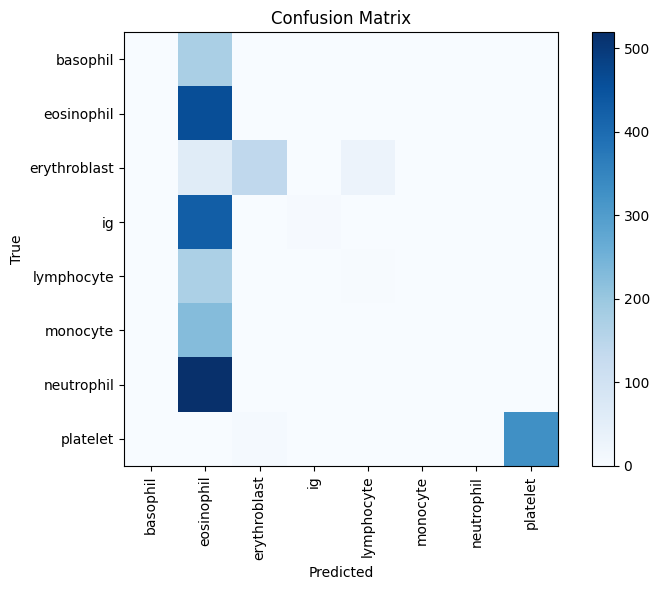

In [27]:
print("=== Custom CNN ===")
cnn_y_true, cnn_y_pred = evaluate_on_test(cnn_model, test_ds, class_names)

=== VGG16 Transfer Learning ===
81/81 ━━━━━━━━━━━━━━━━━━━━ 19s 153ms/step - accuracy: 0.8847 - loss: 0.3430
Test Loss: 0.3430
Test Accuracy: 0.8847

Classification Report:

              precision    recall  f1-score   support

    basophil       0.85      0.91      0.88       180
  eosinophil       0.89      0.87      0.88       458
erythroblast       0.92      0.92      0.92       231
          ig       0.82      0.87      0.84       444
  lymphocyte       0.94      0.84      0.88       182
    monocyte       0.83      0.79      0.81       230
  neutrophil       0.91      0.90      0.90       511
    platelet       0.97      1.00      0.98       331

    accuracy                           0.89      2567
   macro avg       0.89      0.89      0.89      2567
weighted avg       0.89      0.89      0.89      2567



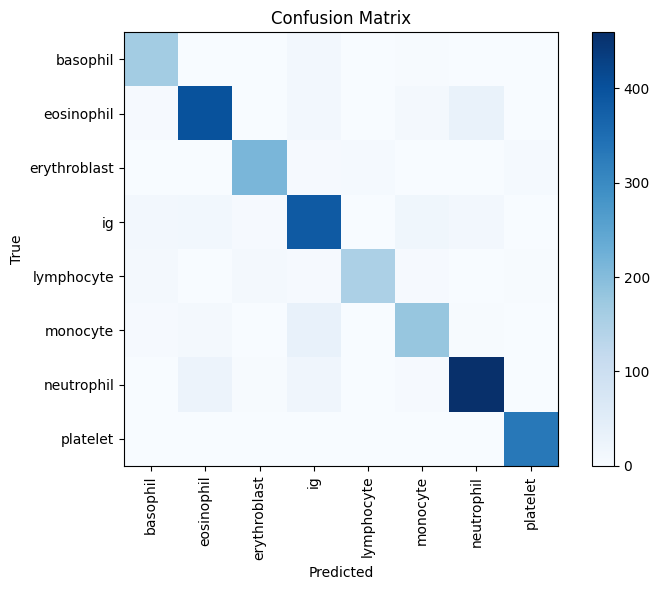

In [28]:
print("=== VGG16 Transfer Learning ===")
vgg_y_true, vgg_y_pred = evaluate_on_test(vgg_model, test_ds, class_names)

## Save the model


In [29]:
cnn_model.save("custom_cnn_pcb.keras")
vgg_model.save("vgg16_pcb.keras")

# Training curve

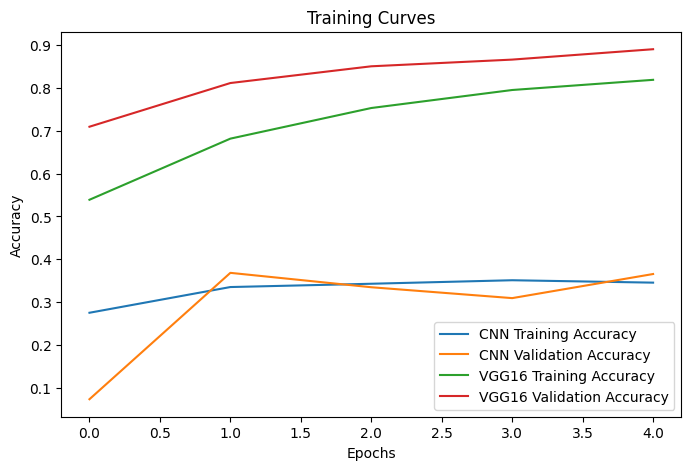

In [30]:
plt.figure(figsize=(8, 5))
plt.plot(cnn_history.history['accuracy'], label='CNN Training Accuracy')
plt.plot(cnn_history.history['val_accuracy'], label='CNN Validation Accuracy')
plt.plot(vgg_history.history['accuracy'], label='VGG16 Training Accuracy')
plt.plot(vgg_history.history['val_accuracy'], label='VGG16 Validation Accuracy')
plt.title('Training Curves')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

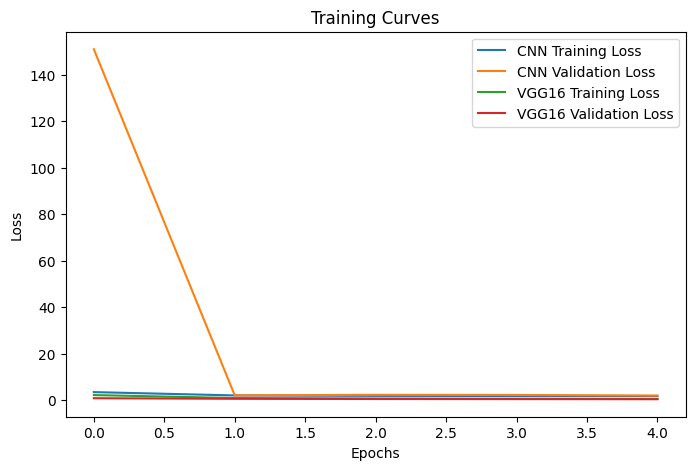

In [31]:
plt.figure(figsize=(8, 5))
plt.plot(cnn_history.history['loss'], label='CNN Training Loss')
plt.plot(cnn_history.history['val_loss'], label='CNN Validation Loss')
plt.plot(vgg_history.history['loss'], label='VGG16 Training Loss')
plt.plot(vgg_history.history['val_loss'], label='VGG16 Validation Loss')
plt.title('Training Curves')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Comparing CNN and VGG model

In [37]:
cnn_loss, cnn_accuracy = cnn_model.evaluate(test_ds, verbose=0)
vgg_loss, vgg_accuracy = vgg_model.evaluate(test_ds, verbose=0)

print("MODEL COMPARISON")
print("------------------------")
print(f"Custom CNN Accuracy: {cnn_accuracy:.4f}")
print(f"VGG16 Accuracy: {vgg_accuracy:.4f}")

print(f"\nCustom CNN Loss: {cnn_loss:.4f}")
print(f"VGG16 Loss: {vgg_loss:.4f}")

MODEL COMPARISON
------------------------
Custom CNN Accuracy: 0.3646
VGG16 Accuracy: 0.8855

Custom CNN Loss: 1.7201
VGG16 Loss: 0.3431


# Predictions

In [33]:
predictions = cnn_model.predict(test_ds)
predicted_classes = np.argmax(predictions, axis=1)

81/81 ━━━━━━━━━━━━━━━━━━━━ 13s 78ms/step


In [35]:
for i in range(10):
    print(f"Image {i + 1}: Predicted Class = {class_names[predicted_classes[i]]}")

Image 1: Predicted Class = eosinophil
Image 2: Predicted Class = eosinophil
Image 3: Predicted Class = erythroblast
Image 4: Predicted Class = eosinophil
Image 5: Predicted Class = lymphocyte
Image 6: Predicted Class = eosinophil
Image 7: Predicted Class = erythroblast
Image 8: Predicted Class = eosinophil
Image 9: Predicted Class = eosinophil
Image 10: Predicted Class = eosinophil


## Display actual vs predicted results

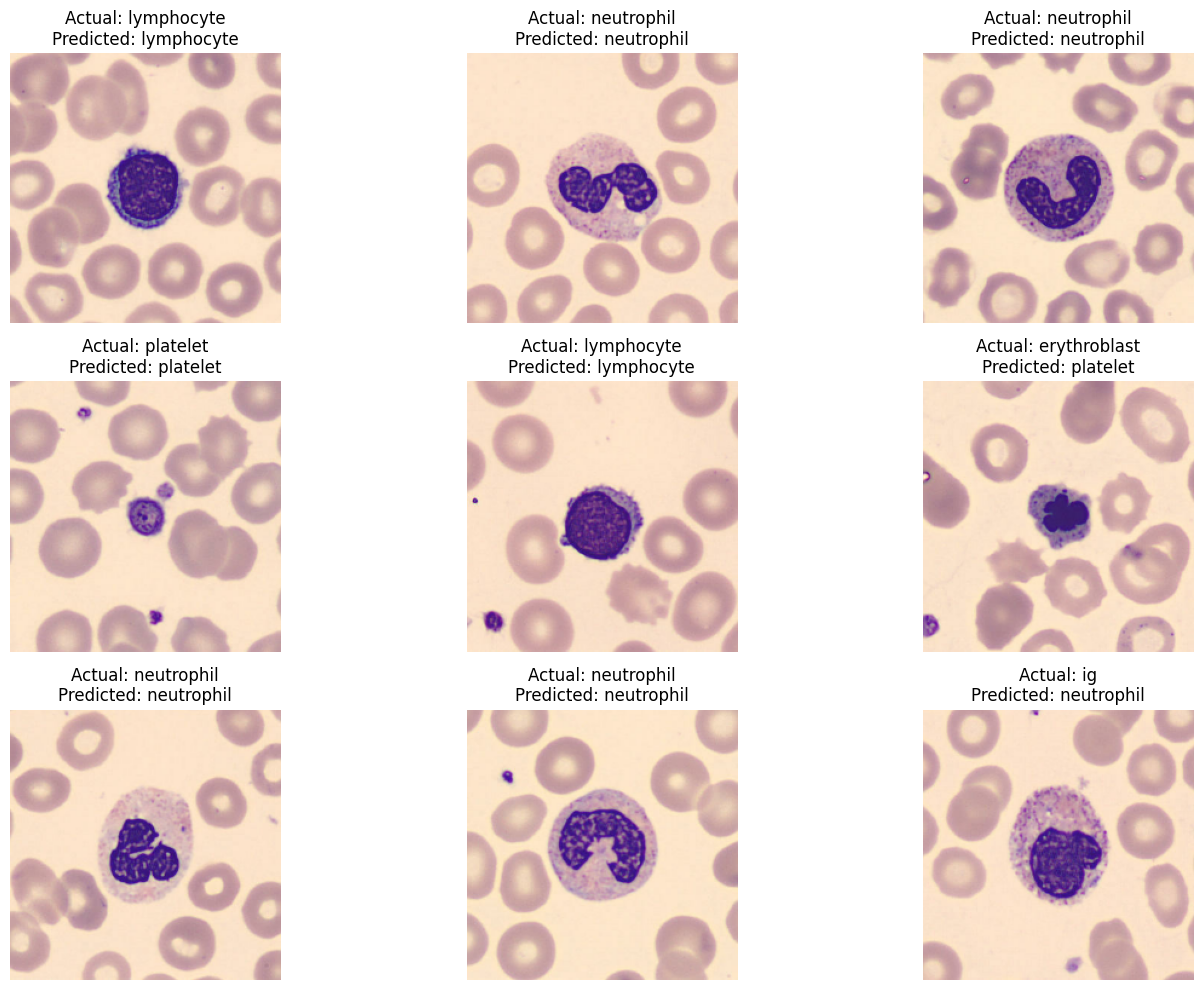

In [38]:
plt.figure(figsize=(15, 10))

for images, labels in test_ds.take(1):

    predictions = vgg_model.predict(images, verbose=0)
    predicted_classes = np.argmax(predictions, axis=1)

    for i in range(9):
        plt.subplot(3, 3, i + 1)

        plt.imshow(images[i].numpy().astype("uint8"))

        actual = class_names[labels[i]]
        predicted = class_names[predicted_classes[i]]

        plt.title(f"Actual: {actual}\nPredicted: {predicted}")
        plt.axis("off")

plt.tight_layout()
plt.show()

## Prediction confidence

In [39]:
for images, labels in test_ds.take(1):

    predictions = vgg_model.predict(images, verbose=0)

    predicted_classes = np.argmax(predictions, axis=1)
    confidence = np.max(predictions, axis=1)

    for i in range(10):
        print(
            f"Actual: {class_names[labels[i]]} | "
            f"Predicted: {class_names[predicted_classes[i]]} | "
            f"Confidence: {confidence[i] * 100:.2f}%"
        )

Actual: platelet | Predicted: platelet | Confidence: 100.00%
Actual: ig | Predicted: ig | Confidence: 99.36%
Actual: neutrophil | Predicted: neutrophil | Confidence: 99.50%
Actual: platelet | Predicted: platelet | Confidence: 47.71%
Actual: neutrophil | Predicted: neutrophil | Confidence: 87.28%
Actual: neutrophil | Predicted: neutrophil | Confidence: 80.30%
Actual: lymphocyte | Predicted: lymphocyte | Confidence: 99.97%
Actual: ig | Predicted: ig | Confidence: 97.89%
Actual: platelet | Predicted: platelet | Confidence: 100.00%
Actual: ig | Predicted: ig | Confidence: 99.23%
